In [ ]:
!pip install roboflow
!pip install ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="ykeC1dFGMvs2alxtfcP9")
project = rf.workspace("bike-helmets").project("bike-helmet-detection-2vdjo")
version = project.version(2)
dataset = version.download("yolov8")

ERROR: Operation cancelled by user


ModuleNotFoundError: No module named 'roboflow'

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [ ]:
img_dir = '/content/Bike-Helmet-Detection-2/train/images/'
label_dir = '/content/Bike-Helmet-Detection-2/train/labels/'

In [ ]:
img_files = os.listdir(img_dir)
label_files = os.listdir(label_dir)
img_name = random.choice(img_files)

In [ ]:
img_path = os.path.join(img_dir, img_name)
label_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))

In [ ]:
img_path, label_path

('/content/Bike-Helmet-Detection-2/train/images/BikesHelmets499_png_jpg.rf.ff1b63a014c092179b9b9b9f313100c7.jpg',
 '/content/Bike-Helmet-Detection-2/train/labels/BikesHelmets499_png_jpg.rf.ff1b63a014c092179b9b9b9f313100c7.txt')

In [ ]:
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape

array([[[ 40,  42,  28],
        [ 49,  52,  35],
        [ 69,  73,  56],
        ...,
        [ 80,  57,  39],
        [ 89,  63,  46],
        [ 93,  68,  48]],

       [[ 34,  36,  23],
        [ 46,  48,  34],
        [ 66,  70,  53],
        ...,
        [ 84,  61,  43],
        [ 92,  67,  47],
        [ 97,  72,  52]],

       [[ 30,  32,  21],
        [ 43,  45,  32],
        [ 60,  64,  47],
        ...,
        [ 90,  67,  49],
        [ 97,  72,  52],
        [101,  76,  56]],

       ...,

       [[148, 136, 114],
        [152, 140, 118],
        [156, 144, 122],
        ...,
        [170, 169, 167],
        [169, 168, 166],
        [168, 167, 165]],

       [[147, 136, 116],
        [151, 140, 120],
        [154, 143, 123],
        ...,
        [167, 166, 164],
        [168, 167, 165],
        [168, 167, 165]],

       [[148, 137, 117],
        [154, 143, 123],
        [156, 145, 125],
        ...,
        [163, 162, 160],
        [165, 164, 162],
        [165, 164, 162]]], dtype=uint8)
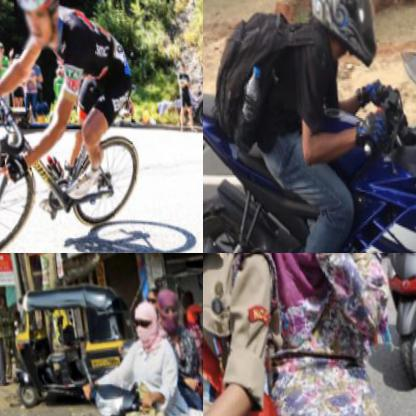

In [ ]:
image

In [ ]:
# In order to draw bounding boxes, we have to access the dimensions of them from the label.txt file for the same image.
if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        lines = f.readlines()
    # Data inside the labels.txt is in following format -
    # class, xcor, ycor, borderwidth, border height
    for line in lines:
        class_id, xcor, ycor, bw, bh = map(float, line.split())

        # Convert YOLO → pixel coords
        x1 = int((xcor - bw/2) * w)
        y1 = int((ycor - bh/2) * h)
        x2 = int((xcor + bw/2) * w)
        y2 = int((ycor + bh/2) * h)

        # Draw box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Class label
        label = "with_helmet" if int(class_id) == 0 else "without_helmet"
        cv2.putText(image, label, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
else:
    print("Label file not found")

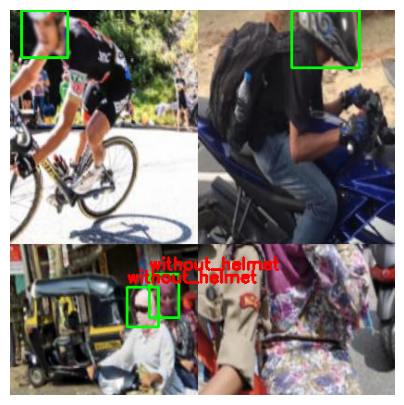

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
!cat '/content/Bike-Helmet-Detection-2/data.yaml'

names:
- With Helmet
- Without Helmet
nc: 2
roboflow:
  license: Public Domain
  project: bike-helmet-detection-2vdjo
  url: https://universe.roboflow.com/bike-helmets/bike-helmet-detection-2vdjo/dataset/2
  version: 2
  workspace: bike-helmets
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
model.train(
    data="/content/Bike-Helmet-Detection-2/data.yaml",
    epochs = 30,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bike-Helmet-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7803ace5b470>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# Validating sample images. ie.. making prediction on a random image from the dataset.
model.val()
model.predict(
    source="/content/Bike-Helmet-Detection-2/test/images/BikesHelmets176_png_jpg.rf.80db740fa43cad753ab10b2c62fa7bc6.jpg",
    conf=0.25,
    save=True
)

Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1241.0±283.3 MB/s, size: 28.2 KB)
val: Scanning /content/Bike-Helmet-Detection-2/valid/labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126 52.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5it/s 3.1s
                   all        126        299       0.78      0.754      0.799      0.364
           With Helmet         88        184       0.75      0.891      0.893      0.401
        Without Helmet         53        115       0.81      0.617      0.704      0.326
Speed: 3.2ms preprocess, 4.7ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val4

image 1/1 /content/Bike-Helmet-Detection-2/test/images/BikesHelmets176_png_jpg.rf.80db7

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'With Helmet', 1: 'Without Helmet'}
 obb: None
 orig_img: array([[[145, 145, 139],
         [145, 145, 139],
         [146, 146, 140],
         ...,
         [251, 253, 247],
         [251, 253, 247],
         [251, 253, 247]],
 
        [[147, 147, 141],
         [146, 146, 140],
         [147, 147, 141],
         ...,
         [251, 253, 247],
         [251, 253, 247],
         [251, 253, 247]],
 
        [[149, 149, 143],
         [149, 149, 143],
         [149, 149, 143],
         ...,
         [251, 252, 248],
         [251, 252, 248],
         [251, 252, 248]],
 
        ...,
 
        [[144, 153, 156],
         [144, 153, 156],
         [143, 153, 153],
         ...,
         [169, 168, 164],
         [168, 167, 163],
         [167, 166, 162]],
 
        [[141, 150, 153],
         [141, 150, 153],
         [141, 151, 151],
      

In [ ]:
model = YOLO('/content/best.pt')

NameError: name 'YOLO' is not defined

In [ ]:
model.val()
model.predict(
    source='/content/Bike-Helmet-Detection-2/test/images/BikesHelmets618_png_jpg.rf.ba31a4331f163c7786cdccce6ec94a64.jpg',
    conf=0.25,
    save=True
)

NameError: name 'model' is not defined

# Dealing With Video part Starts From Here

In [6]:
!pip install ultralytics opencv-python

In [7]:
from ultralytics import YOLO
import cv2
import os

In [9]:
video_path = '/content/Traffic_video_1.mp4'

In [10]:
cap = cv2.VideoCapture(video_path)
output_width = 960
output_height = 540
fps = int(cap.get(cv2.CAP_PROP_FPS))

In [11]:
fps

0

In [ ]:
dir = './'

In [ ]:
# Creating Output Video writer in order to draw bounding boxes on the video file.
import cv2

cap = cv2.VideoCapture(
    "./Traffic_video_1.mp4"
)

fps = cap.get(cv2.CAP_PROP_FPS)

if fps <= 0:
    fps = 25  # safe fallback

output_width = 960
output_height = 540

out = cv2.VideoWriter(
    "/Users/harshchandrul/Documents/Major-Project-1/output_video.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps / 5,  # because frame_skip = 5
    (output_width, output_height),
)

In [26]:
from google.colab.patches import cv2_imshow
import time

In [27]:
# This is overlap function used to check how much of person lower body intersects whith mototrcycles upper body
def overlap(box_a, box_b):  # box_a = person_box, box_b = mototrcycle_box
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    if inter_x2 <= inter_x1 or inter_y2 <= inter_y1:
        return 0

    inter_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
    areaA = (ax2 - ax1) * (ay2 - ay1)
    areaB = (bx2 - bx1) * (by2 - by1)

    return inter_area / min(areaA, areaB)


In [28]:
association_counter = {}
riders = {}

OVERLAP_THRESHOLD = 0.2
N_FRAMES = 5
RIDER_TIMEOUT = 15

In [29]:
# This is the lock() function which locks the person as rider 
def lock(pid, mid, frame_count):
    riders[pid] = {
        "bike": mid, 
        "locked_at": frame_count,
        "last_seen": frame_count
    }

In [30]:
from collections import defaultdict, deque
association_history = defaultdict(lambda: deque(maxlen=10))
first_seen = {}
riders = {}

frame_skip = 5
frame_count = 0
EARLY_FRAMES = 3

# For each Frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    if frame_count % frame_skip != 0:
        continue

    # We have put these dictionaries inside the loop because we want them to change with every frame, this will make sure that only persons and bikes which are in current frame are present in the dict and not all persons and bikes throughout the history of video 
    persons = {}
    motorcycles = {}

    # We are resizing every frame here to reduce computation size and make the detections faster . 
    frame = cv2.resize(frame, (output_width, output_height))
    
    # Detect And Track
    results = model.track(
        frame,
        imgsz=960,
        tracker="bytetrack.yaml",
        persist=True,
        conf=0.15,
        iou=0.5,
        classes=[0, 3]  # person, motorcycle
    )


    # The whole purpose of this logic is to estabalish the association between motorcycle and person to differentiate between riders and pedestrians
    r = results[0]
    print(type(r.boxes))
    print(r.boxes.id)


    # This is the detection loop
    if r.boxes.id is not None:
        # this will give the dimensions and size of the boxes
        boxes = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)
        track_ids = r.boxes.id.cpu().numpy().astype(int)

        for box, class_id, track_id in zip(boxes, classes, track_ids):
            x1, y1, x2, y2 = box.astype(int)
            if class_id ==0:  # Person
                persons[track_id] = (x1, y1, x2, y2)

            elif class_id == 3:  # Motorcycle
                motorcycles[track_id] = (x1, y1, x2, y2)


    annotated_frame = results[0].plot()


    # Logic for checking if the person is rider or pedestrian
    # Step - 1 Defining Regions

    # for each person in the persons dictionary
    for pid, pbox in persons.items():
        # To get dimensions and lower half of the person 
        px1, py1, px2, py2 = pbox
        ph = py2 - py1
        person_lower = (px1, int(py1 + ph * 0.5), px2, py2)

        # This condition will check if the person appeared in the frame for the first time or if it is a already present person  
        if pid not in first_seen:
            first_seen[pid] = frame_count

        # This condition will check if the person have already been identified as rider previously or not. If it have been identified as a rider already , then we will skip the rest of the loop . 
        if pid in riders:
            riders[pid]["last_seen"] = frame_count
            break

        # sort bikes by horizontal distance to person
        motorcycles_sorted = sorted(
            motorcycles.items(),
            key=lambda x: abs(
            ((x[1][0] + x[1][2]) // 2) - pcx
            )
        )
        
        # For each motorcycle in mototrcycles dictionary
        for mid, mbox in motorcycles_sorted:
            # To get dimensions and upper half of the motorcycle 
            mx1, my1, mx2, my2 = mbox
            mh = my2 - my1
            motorcycle_upper = (mx1, my1, mx2, int(my1 + mh * 0.5))

            # Compute overlap
            ov = overlap(person_lower, motorcycle_upper)
            key = (pid, mid)
            ov_okay = ov > OVERLAP_THRESHOLD

            # Before we were only checking if the rider overlaps the bike, but that was not very reliable so now we will also compute the center of the person and the centere of the bike to see if the person is rider. 

            # To get center of the person- 
            pcx = (px1 + px2) // 2      # pcx - person center x cordinates
            pcy = (py1 + py2) // 2      # pcy - person center y cordinates
            mcx = (mx1 + mx2) // 2
            mcy = (my1 + my2) // 2
            # Compute vertica_ok
            vertical_ok = pcy < mcy     # This means that person is above the motorcycle

            # Compute horizontal_ok
            horizontal_ok = abs(pcx - mcx) < 0.6 * (mx2 - mx1)

            # Rider evidence Rule
            evidence = sum([ov_okay, vertical_ok, horizontal_ok])

            # If 2 or more than 2 conditions are true, that means that the person is a rider. 
            if evidence >= 2:
                association_history[key].append(True)
            else: 
                association_history[key].append(False)


            # Fast Provisional Lock
            # If in the first few frames, strong signal appears of rider, then lock it immidieately
            if frame_count - first_seen[pid] <= EARLY_FRAMES:
                if evidence >= 2 and ov > 0.15:
                    # Lock rider immidieately
                    lock(pid, mid, frame_count)
                    break

            # Normal Lock
            if sum(association_history[key]) >= 4:
                # Lock rider
                lock(pid, mid, frame_count)
                break

            

            # Old Code 
            # if ov > OVERLAP_THRESHOLD:
            #     association_counter[key] = association_counter.get(key, 0) + 1
            # else:
            #     association_counter[key] = max(association_counter.get(key, 0) - 1, 0)

            # Lock rider
            # if association_counter[key] >= N_FRAMES:
            #     riders[pid] = {
            #         "bike": mid,
            #         "last_seen": frame_count
            #     }

            # if association_counter[key] >= N_FRAMES:
            #     print(f"LOCKED RIDER: Person {pid} -> Bike {mid}")


        # This is a list which contain persons which were previously identified as riders but are not in the video frames anymore. This removes those persons in order to reduce computational costs. 
        expired = []
        for pid, data in riders.items():
            if frame_count - data["last_seen"] > RIDER_TIMEOUT:
                expired.append(pid)

        for pid in expired:
            del riders[pid]


    # This part should be within the loop to draw bounding box on each detected person
    for pid in riders:
        if pid in persons:
            px1, py1, px2, py2 = persons[pid]
            cv2.rectangle(
                annotated_frame,
                (px1, py1),
                (px2, py2),
                (0, 0, 255),
                2
            )

    # valid_keys = set(
    #     (pid, mid)
    #     for pid in persons
    #     for mid in motorcycles
    # )

    # association_counter = {
    #     k: v for k, v in association_counter.items()
    #     if k in valid_keys
    # }

    # This line writes the processed frame after the detection and traking of people and bikes to the output file    
    out.write(annotated_frame)


cap.release()
out.release()


In [ ]:
from google.colab import files
files.download("/content/output_tracked.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Okay so now model have produced output video and i have seen how its tracking. Here are the insights -


1. So the model is able to properly verify the bikes and people which are near the camera. Though its having a bit difficult to recognize people that are very far away from camera and because they are far, their size is small and they also appear to be crowded ( because so many vehicles) it was ale to detect almost 70-80% of the  persons and motorbikes. thought it was not able to identify the motorbikes and people at th very back and its understandable because there all are so crowded and congested and small.


2. model seems to have a bit easier time identifying the objects coming toward it compared to objects which are moving away from it.

**Reason:**

	•	Objects moving toward camera:
	•	grow in size over frames
	•	have clearer edges
	•	less occlusion
	•	Objects moving away:
	•	shrink
	•	get occluded
	•	less texture detail

**Real-world fix:**

	•	Multi-camera setups
	•	Different camera angles
	•	Zone-based detection (only detect in “effective zone”)


3. the good thing is that when the tracker loses the tracking for some objects and when it tracks them again, the original/old id of them is preserved and no new id is allocated to them.
